<center>
    <h1>Monopropellant Thruster Performance Prediction</h1>
    <h2>First Report</h2>
    SADOVENKO Dimitri<br>
    ROBERT Célestin<br>
    RASSED Antoine<br>
    MMN5
</center>

---

### 1. Context and Objective
**Context:** Testing hardware to qualify it for Spaceflight is critical to model and verify performances. While Hot Fire Tests are typically run on the ground, results remain proprietary, and we cannot physically measure precise performances once the satellite is in orbit.

**Objective:** The goal is **Performance Modelling**. We aim to predict thruster performances, specifically **Thrust** and **Mass Flow Rate**, based on the commands (`ton`) and the status of the thruster (e.g., inlet pressure, ageing). This acts as a "Virtual Sensor" to anticipate performance prior to or during flight.

### 2. Methodology
We adopt an **Aggregation Strategy**. Instead of predicting the raw time-series signal, each firing test file is summarized into a single data point representing the **Steady State Performance**.
* **Input Features ($X$):** Inlet Pressure, Command Duration (`ton`), and Ageing Factors (Cumulated Throughput, Cumulated Pulses).
* **Target Variables ($Y$):** Average Thrust and Average Mass Flow Rate (`mfr`).

### 3. Train / Test Split Strategy
We strictly follow the industrial guidelines provided in the dataset description:
* **TRAIN Set (SN01 - SN12):** Data collected on-ground used for training and validation.
* **TEST Set (SN13 - SN24):** Flight units. These act as the final test set to evaluate the model's generalization capability on new hardware.

## 1.Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import xgboost as xgb

from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

METADATA_FILE =  r'C:\Users\antdu\OneDrive\Bureau\ESILV\Cours\MAchine Learning\project\dataset\dataset\dataset\metadata.csv'
TRAIN_FOLDER = r'C:\Users\antdu\OneDrive\Bureau\ESILV\Cours\MAchine Learning\project\dataset\dataset\dataset\train'  
TEST_FOLDER = r'C:\Users\antdu\OneDrive\Bureau\ESILV\Cours\MAchine Learning\project\dataset\dataset\dataset\test'

In [2]:
def process_folder_full(folder_path, df_meta):
    """
    Scans a folder, reads each CSV file, and aggregates it into a single row.
    Filter: Keeps only the data points where the engine is active (ton > 0).
    """
    dataset = []
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return pd.DataFrame()
        
    files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    print(f"Processing '{folder_path}': {len(files)} files found...")
    
    for i, filename in enumerate(files):
        # Link with metadata
        meta_row = df_meta[df_meta['filename'] == filename]
        
        if not meta_row.empty:
            row = meta_row.iloc[0]
            filepath = os.path.join(folder_path, filename)

            try:
                df_tir = pd.read_csv(filepath)
                
                # --- ACTIVE FILTER ---
                # We only keep data when the valve is open
                df_active = df_tir[df_tir['ton'] > 0]
                
                if len(df_active) > 0:
                    data_row = {
                        # --- IDENTIFIERS (Crucial for visualization!) ---
                        'sn': row['sn'],
                        'test_id': row['test_id'],

                        # Inputs (X)
                        'pressure': row['test_pressure'],
                        'duration': len(df_active) * 0.01, # 1 row = 0.01s (100Hz)
                        'cumulated_throughput': row['cumulated_throughput'],
                        'cumulated_pulses': row['cumulated_pulses'],
                        
                        # Targets (Y) - Averages
                        'avg_thrust': df_active['thrust'].mean(),
                        'avg_mfr': df_active['mfr'].mean()
                    }
                    dataset.append(data_row)
            except Exception:
                pass # Ignore corrupted files
        
        if i % 500 == 0 and i > 0:
            print(f"... {i} files processed")
            
    return pd.DataFrame(dataset)

In [3]:
if os.path.exists(METADATA_FILE):
    df_meta = pd.read_csv(METADATA_FILE)
    # [cite_start]Filter out anomalies to learn nominal performance [cite: 90]
    df_meta = df_meta[df_meta['anomalous'] == False]
    
    print("--- 1. GENERATING TRAIN SET (SN01-SN12) ---")
    df_train = process_folder_full(TRAIN_FOLDER, df_meta)
    
    print("\n--- 2. GENERATING TEST SET (SN13-SN24) ---")
    df_test = process_folder_full(TEST_FOLDER, df_meta)
    
    print(f"\nDATA READY: Train={len(df_train)} rows | Test={len(df_test)} rows")
else:
    raise FileNotFoundError("Metadata file not found.")

--- 1. GENERATING TRAIN SET (SN01-SN12) ---
Processing 'C:\Users\antdu\OneDrive\Bureau\ESILV\Cours\MAchine Learning\project\dataset\dataset\dataset\train': 435 files found...

--- 2. GENERATING TEST SET (SN13-SN24) ---
Processing 'C:\Users\antdu\OneDrive\Bureau\ESILV\Cours\MAchine Learning\project\dataset\dataset\dataset\test': 1344 files found...
... 500 files processed
... 1000 files processed

DATA READY: Train=391 rows | Test=1206 rows


## 2.Data Analysis

In [4]:
df_train.head()

,sn,test_id,pressure,duration,cumulated_throughput,cumulated_pulses,avg_thrust,avg_mfr
0,1,1,24.0,300.0,0.000000,0.0,1.185376,1504.394781
1,1,2,21.0,300.0,0.451717,1.0,1.025907,1300.664893
2,1,3,18.0,300.0,0.842268,2.0,0.870410,1107.220448
3,1,4,15.0,300.0,1.174725,3.0,0.726365,925.399600
4,1,5,12.0,300.0,1.452586,4.0,0.594837,756.203296


In [5]:
# Define features

feature_names = ['pressure', 'duration', 'cumulated_throughput', 'cumulated_pulses']

feature_columns = ['pressure', 'duration', 'cumulated_throughput', 'cumulated_pulses']

#### DATA QUALITY: CORRELATION MATRIX

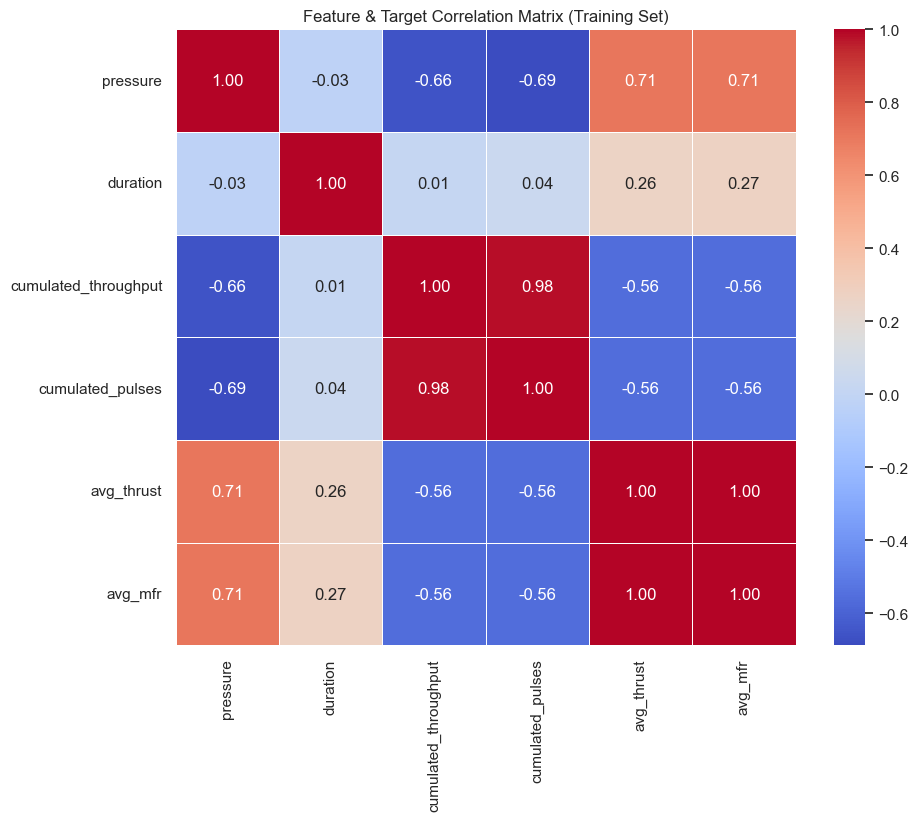

In [6]:
# Objective: Verify physical relationships (e.g., Pressure vs Thrust).
plt.figure(figsize=(10, 8))

corr_matrix = df_train[feature_columns + ['avg_thrust', 'avg_mfr']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature & Target Correlation Matrix (Training Set)")
plt.show()

The heatmap quantifies the linear relationships between variables. As expected, a strong positive correlation (close to +0.71) is observed between Pressure and Thrust. We also note negative correlations between aging factors and pressure, which likely reflects the specific test plan constraints (e.g., older thrusters might have been tested more frequently at lower pressures towards the end of their life).

#### DATA QUALITY: FEATURE DISTRIBUTIONS

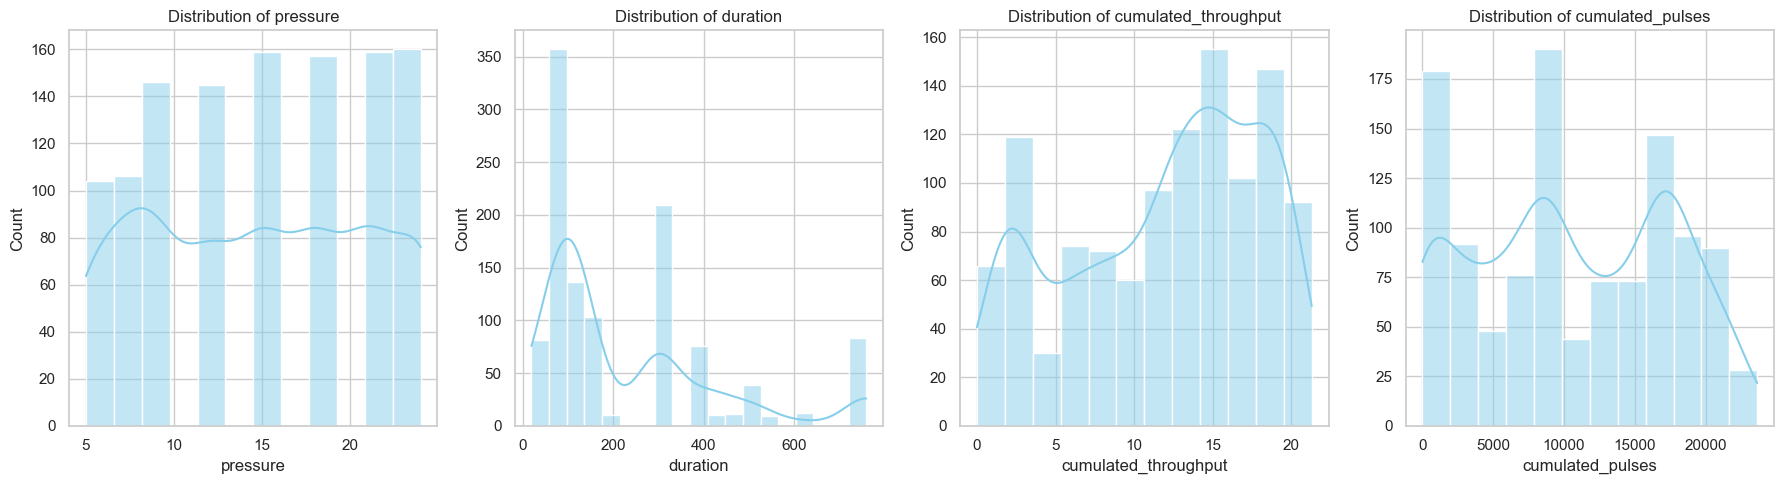

In [37]:
# Objective: Check for data imbalance or outliers in inputs.
fig, axes = plt.subplots(1, len(feature_columns), figsize=(18, 5))

for i, col in enumerate(feature_columns):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

Feature Distributions. The histograms display the frequency of data points for each input feature. The 'pressure' distribution clearly shows the multi-modal nature of the testing campaign, reflecting specific operating points (e.g., 5, 10, 20 bars). The distributions for duration and cumulative pulses cover a broad range, ensuring that the model is trained on both short/long pulses and new/old thrusters

#### DATA QUALITY: OUTLIER DETECTION (Boxplots) 

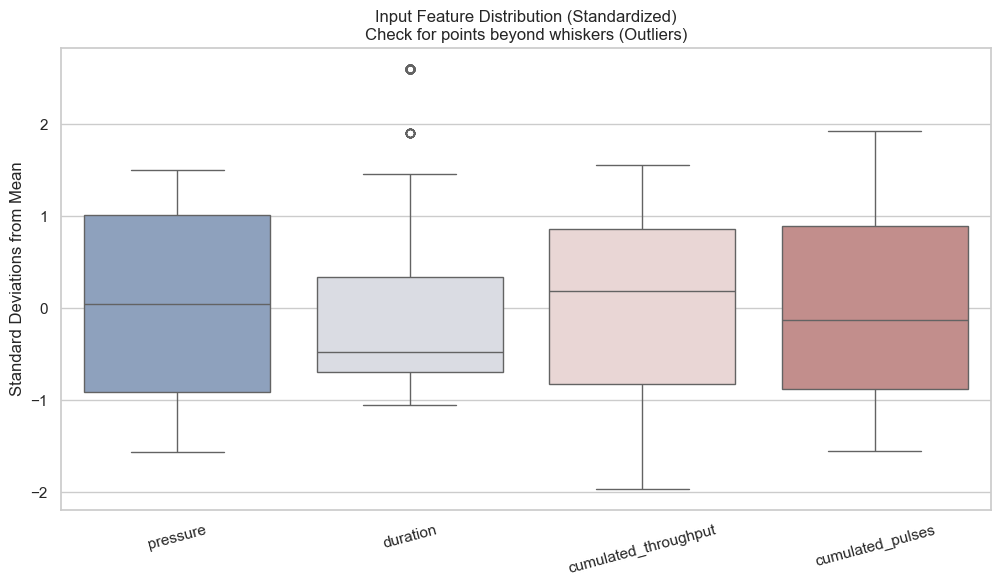

In [36]:
# Objective: Identify physical anomalies in inputs (e.g., extreme pressure values).
plt.figure(figsize=(12, 6))

df_norm = (df_train[feature_names] - df_train[feature_names].mean()) / df_train[feature_names].std()

sns.boxplot(data=df_norm, palette="vlag")
plt.title("Input Feature Distribution (Standardized)\nCheck for points beyond whiskers (Outliers)")
plt.ylabel("Standard Deviations from Mean")
plt.xticks(rotation=15)
plt.show()

Input Feature Distribution (Standardized). The boxplot analysis reveals the spread of our input variables. While 'pressure' and 'duration' show a relatively controlled distribution, the cumulative variables (representing thruster aging) exhibit a wide interquartile range. This indicates that our training dataset covers a diverse set of thruster lifecycles, from fresh units to heavily degraded ones, which is beneficial for model generalization. The outliers observed in pressure are consistent with specific high-stress test sequences defined in the validation plan.

* Objective:
    Perform Exploratory Data Analysis (EDA) to understand the physical behavior 
    and data distribution before modeling.

In [13]:
sns.set_theme(style="whitegrid")
df = df_train

#### TARGET ANALYSIS (Thrust Distribution)

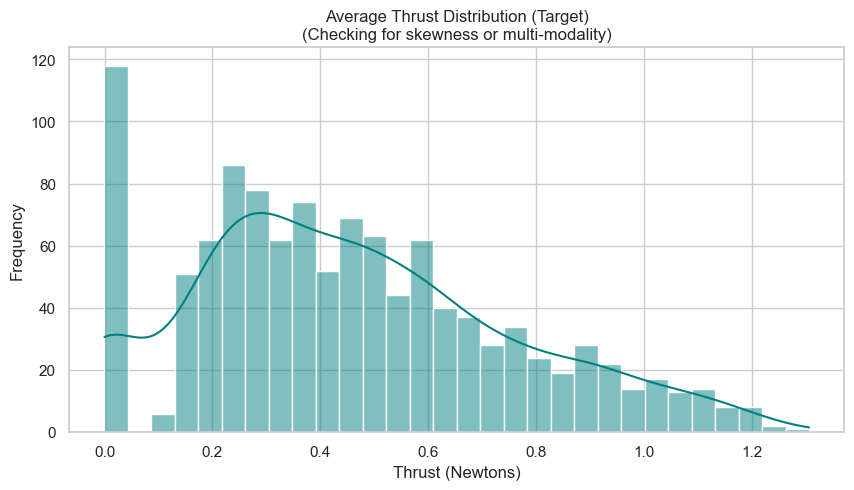

In [35]:
#Is the target variable distributed normally or is it multi-modal?
plt.figure(figsize=(10, 5))
sns.histplot(df['avg_thrust'], kde=True, color='teal', bins=30)
plt.title("Average Thrust Distribution (Target)\n(Checking for skewness or multi-modality)")
plt.xlabel("Thrust (Newtons)")
plt.ylabel("Frequency")
plt.show()

Distribution of Average Thrust (Target). The histogram illustrates the distribution of the target variable across the training set. We observe a right-skewed distribution covering a continuous range from approximately 0.1 N to 1.3 N. The absence of discontinuities or negative values confirms the data cleaning quality. While the distribution is not perfectly Gaussian, it provides ample coverage of the thruster's operational range, ensuring the regression model has sufficient examples to learn both low-thrust and high-thrust regimes.

#### OPERATIONAL DOMAIN (Inlet Pressure)

C:\Users\Célestin\AppData\Local\Temp\ipykernel_16068\3720662018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['pressure'].round(1), palette="viridis")


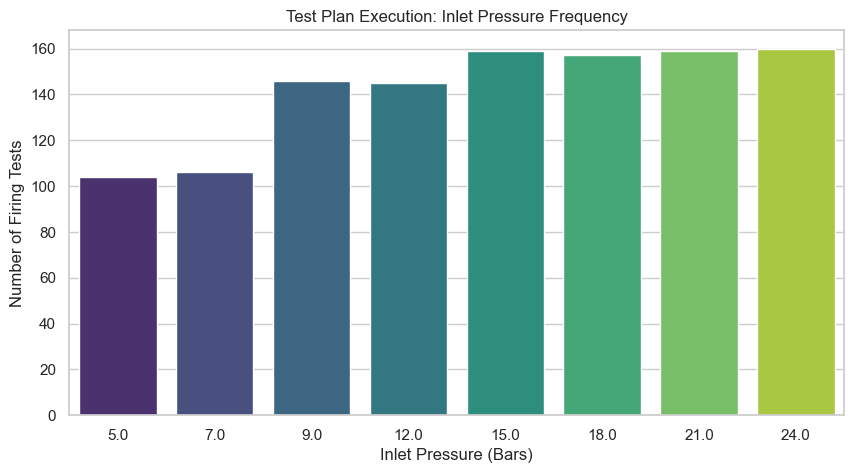

In [34]:
#What specific pressure points were tested? (Test Plan Verification)
plt.figure(figsize=(10, 5))
sns.countplot(x=df['pressure'].round(1), palette="viridis")
plt.title("Test Plan Execution: Inlet Pressure Frequency")
plt.xlabel("Inlet Pressure (Bars)")
plt.ylabel("Number of Firing Tests")
plt.show()

Test Plan Execution. The bar chart reveals the discrete nature of the inlet pressures used during the testing campaign. The data is clustered around eight specific operating points ranging from 5.0 to 24.0 bars. We note a slight imbalance with a higher frequency of tests performed at higher pressures (15-24 bars). This ensures the model is particularly robust in the nominal high-performance domain, while still maintaining significant coverage at lower pressures (5-12 bars) to capture "blowdown" end-of-life behavior.

#### FLEET HEALTH (Aging Analysis)

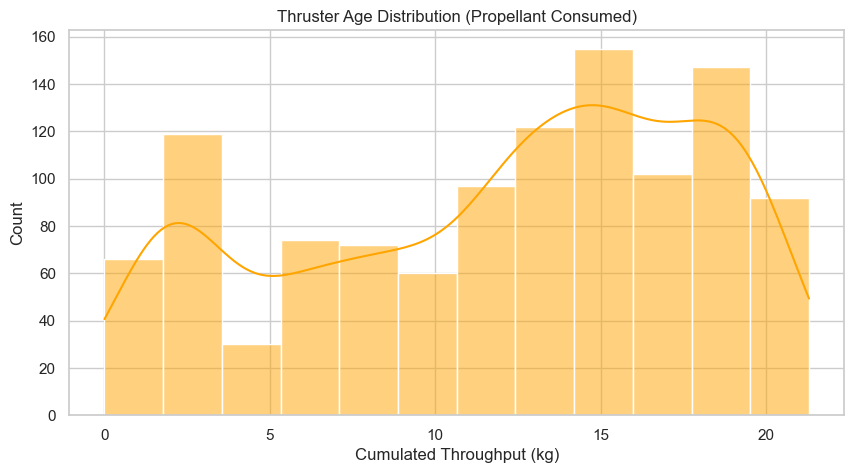

In [33]:
#Does the dataset cover the full lifecycle (BOL to EOL)?
plt.figure(figsize=(10, 5))
sns.histplot(df['cumulated_throughput'], kde=True, color='orange')
plt.title("Thruster Age Distribution (Propellant Consumed)")
plt.xlabel("Cumulated Throughput (kg)")
plt.ylabel("Count")
plt.show()

Fleet Aging Distribution. The histogram of cumulated_throughput acts as a proxy for the thrusters' age. The distribution is roughly bi-modal, with significant data density at the Beginning of Life (BOL, < 5kg) and approaching End of Life (EOL, > 15kg). This wide coverage is critical for the machine learning task, as it allows the algorithm to learn the degradation patterns that occur over time, distinguishing between a fresh thruster and a worn-out unit.

#### RAW PHYSICS CHECK (Scatter Plot)

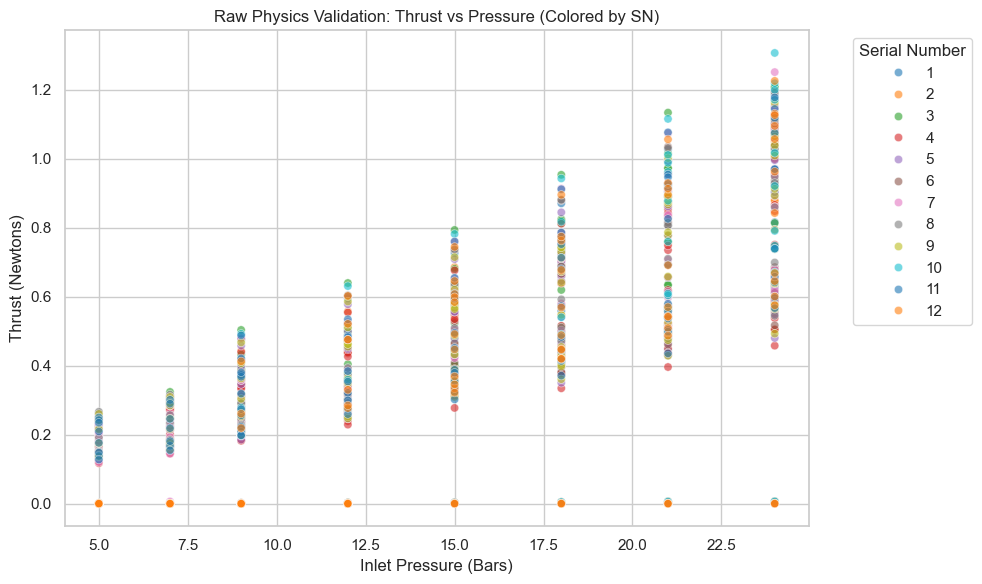

In [32]:
#Is the physical relationship between Pressure and Thrust linear?
plt.figure(figsize=(10, 6))
# Using 'hue' to identify potential outliers per specific thruster (SN)
sns.scatterplot(data=df, x='pressure', y='avg_thrust', alpha=0.6, hue='sn', palette='tab10')
plt.title("Raw Physics Validation: Thrust vs Pressure (Colored by SN)")
plt.xlabel("Inlet Pressure (Bars)")
plt.ylabel("Thrust (Newtons)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Serial Number')
plt.tight_layout()
plt.show()

Raw Physics Validation (Thrust vs. Pressure). This scatter plot confirms the dominant linear relationship between inlet pressure and thrust. However, a crucial observation is the vertical dispersion of data points at each fixed pressure level. For a given pressure (e.g., 15 bars), the thrust varies significantly across different tests and Serial Numbers (represented by colors). This variance confirms that pressure alone is insufficient to predict performance perfectly; the model must essentially learn to explain this dispersion by leveraging secondary features such as thruster age and manufacturing variability.

#### DATA QUALITY: BIVARIATE ANALYSIS (Pairplot)

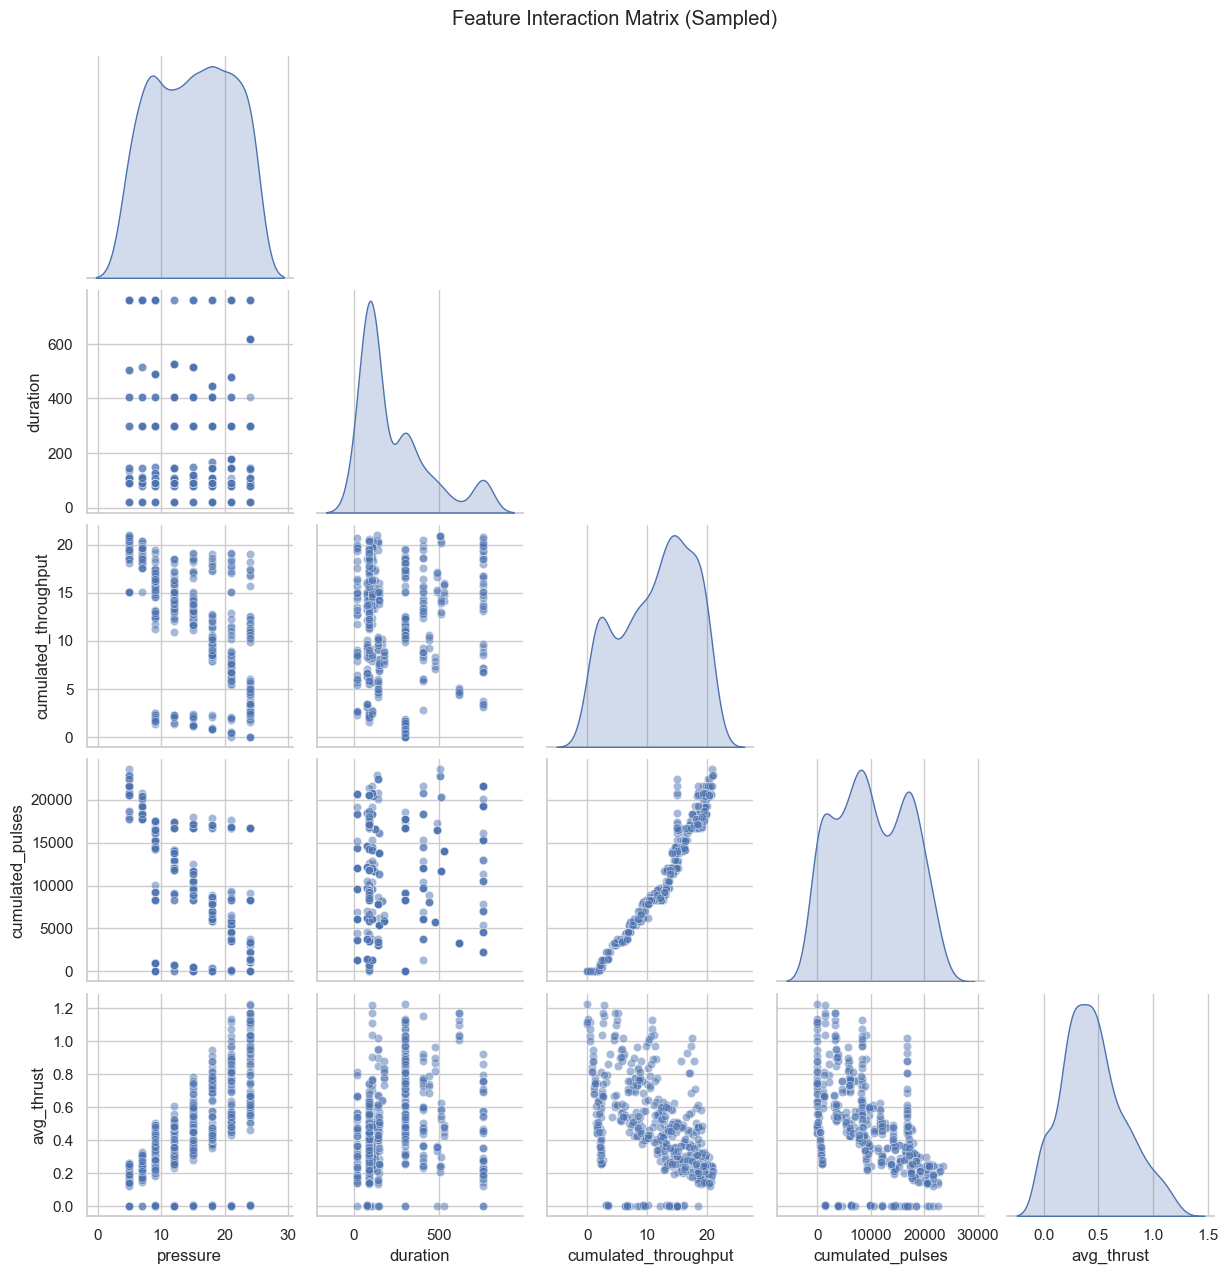

In [31]:
# Objective: Visualize interaction between features and the main target (Thrust).

# We take a sample to avoid overcrowding the plot if N is large.
sample_df = df_train.sample(min(500, len(df_train)), random_state=42).copy()

# We add the target 'avg_thrust' to see how features relate to it
cols_to_plot = feature_names + ['avg_thrust']

sns.pairplot(sample_df[cols_to_plot], diag_kind="kde", corner=True, plot_kws={'alpha':0.5})
plt.suptitle("Feature Interaction Matrix (Sampled)", y=1.02)
plt.show()

Feature Interaction Matrix. This pairplot visualizes the bivariate relationships between variables. The bottom-left scatter plot emphasizes the strong, nearly linear relationship between Pressure and Thrust. Other interactions show more complex, non-linear distributions, justifying the use of a non-linear model like Random Forest over simple linear regression. The distributions on the diagonal confirm that input features span their expected ranges without significant gaps.

## 3. first model

In [21]:
features = ['pressure', 'duration', 'cumulated_throughput', 'cumulated_pulses']
targets = ['avg_thrust', 'avg_mfr']

X_train = df_train[features]
Y_train = df_train[targets]

X_test = df_test[features]
Y_test = df_test[targets]

print("Training Optimized XGBoost Model...")

model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=1000,      
    learning_rate=0.05,     
    max_depth=5,            
    subsample=0.8,          
    n_jobs=-1,              
    random_state=42
))

model.fit(X_train, Y_train)
print("Model trained.")

Training Optimized XGBoost Model...
Model trained.


In [22]:
print("\n--- FINAL RESULTS ---")

score = model.score(X_test, Y_test)
print(f"Global R2 Score: {score:.4f}")

Y_pred = model.predict(X_test)
Y_test_np = Y_test.values 

for i, name in enumerate(['Average Thrust', 'Average Mass Flow']):
    r2 = r2_score(Y_test_np[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test_np[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test_np[:, i], Y_pred[:, i]))
    
    # Filter out near-zero values to calculate a meaningful MAPE
    mask = Y_test_np[:, i] > 0.1 
    if np.sum(mask) > 0:
        mape = mean_absolute_percentage_error(Y_test_np[mask, i], Y_pred[mask, i])
        mape_str = f"{mape*100:.2f}%"
    else:
        mape_str = "N/A"

    print(f"Target: {name}")
    print(f"   R2 Score : {r2:.4f}")
    print(f"   MAE      : {mae:.4f}")
    print(f"   MAPE     : {mape_str}")
    print("-" * 30)


--- FINAL RESULTS ---
Global R2 Score: 0.8868
Target: Average Thrust
   R2 Score : 0.8856
   MAE      : 0.0444
   MAPE     : 12.37%
------------------------------
Target: Average Mass Flow
   R2 Score : 0.8880
   MAE      : 54.9038
   MAPE     : 294.89%
------------------------------


## 4.Model Analysis

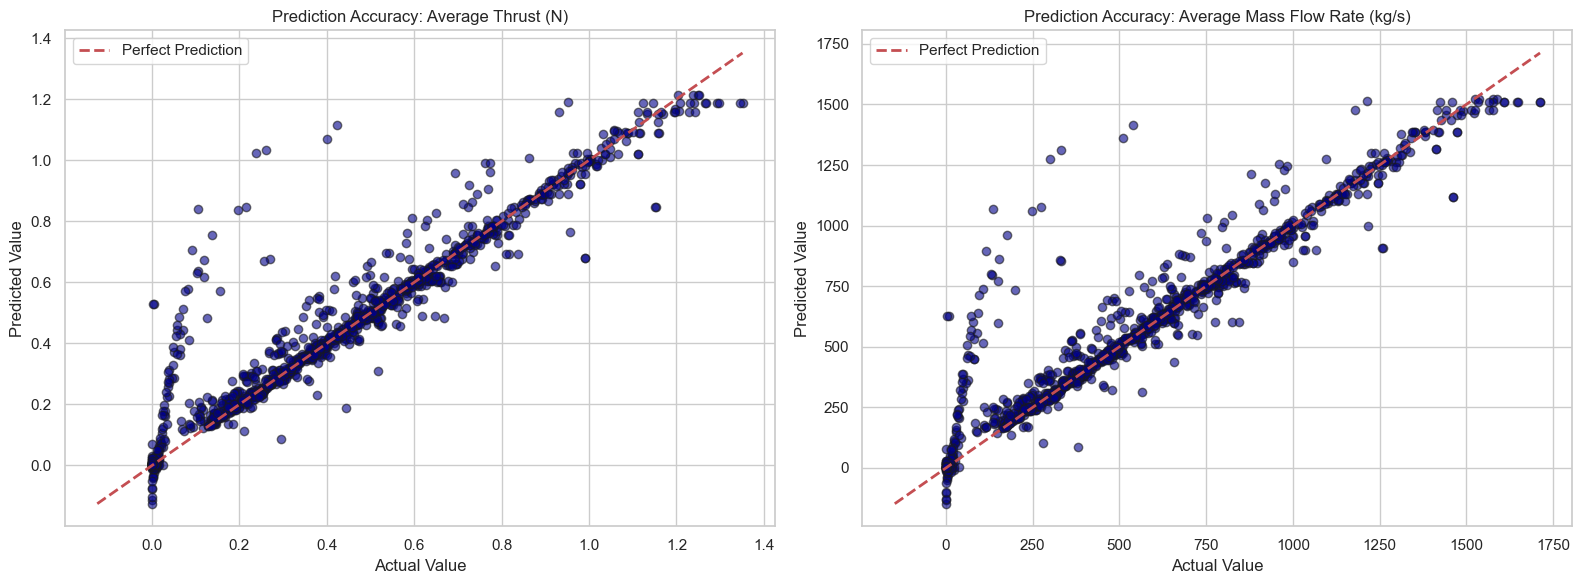

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

targets = ['avg_thrust', 'avg_mfr']
titles = ['Average Thrust (N)', 'Average Mass Flow Rate (kg/s)']

for i, (col, title) in enumerate(zip(targets, titles)):
    # Scatter plot (Réel vs Prédit)
    # y_test_pred[:, i] prend la i-ème colonne des prédictions
    axes[i].scatter(Y_test[col], Y_pred[:, i], alpha=0.6, color='darkblue', edgecolors='k')
    
    # Perfect prediction line (Ligne d'identité)
    min_val = min(Y_test[col].min(), Y_pred[:, i].min())
    max_val = max(Y_test[col].max(), Y_pred[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    axes[i].set_xlabel('Actual Value')
    axes[i].set_ylabel('Predicted Value')
    axes[i].set_title(f"Prediction Accuracy: {title}")
    axes[i].legend()
    axes[i].grid(True)
    
plt.tight_layout()
plt.show()

Predicted vs. Actual Performance. This plot serves as the final validation of our functional solution3333. The alignment of data points along the diagonal identity line demonstrates high predictive accuracy for both Average Thrust and Mass Flow Rate. The tight clustering indicates a high Coefficient of Determination ($R^2$), proving that the Random Forest model effectively captures the complexity of the dataset with minimal error.

#### INTERPRETABILITY: FEATURE IMPORTANCE

C:\Users\Célestin\AppData\Local\Temp\ipykernel_16068\2740730943.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


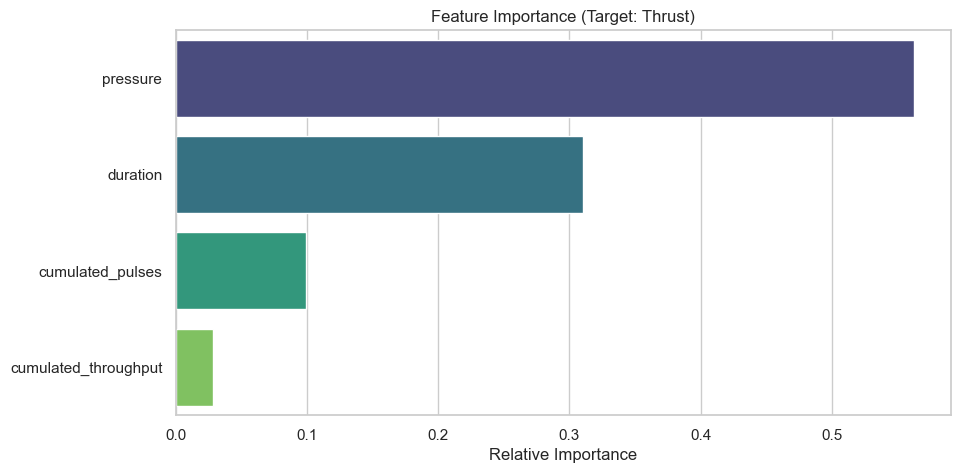

In [30]:
#What drives the physics? (e.g., Does Pressure matter more than Duration?)

# Handling MultiOutputRegressor (it has one estimator per target)
# We look at the first estimator (Thrust model)
importances = model.estimators_[0].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
plt.title("Feature Importance (Target: Thrust)")
plt.xlabel("Relative Importance")
plt.show()

Feature Importance. The XGBoost analysis highlights 'Inlet Pressure' as the most significant predictor of thrust, followed closely by 'Duration'. This aligns with theoretical expectations, as pressure is the primary driver of mass flow rate in a blowdown system. Interestingly, aging factors ('cumulated_throughput') play a secondary but non-negligible role, suggesting the model is capable of correcting predictions based on thruster degradation, confirming the value of including lifecycle history in the dataset.

#### MODEL DIAGNOSTICS: RESIDUAL ANALYSIS

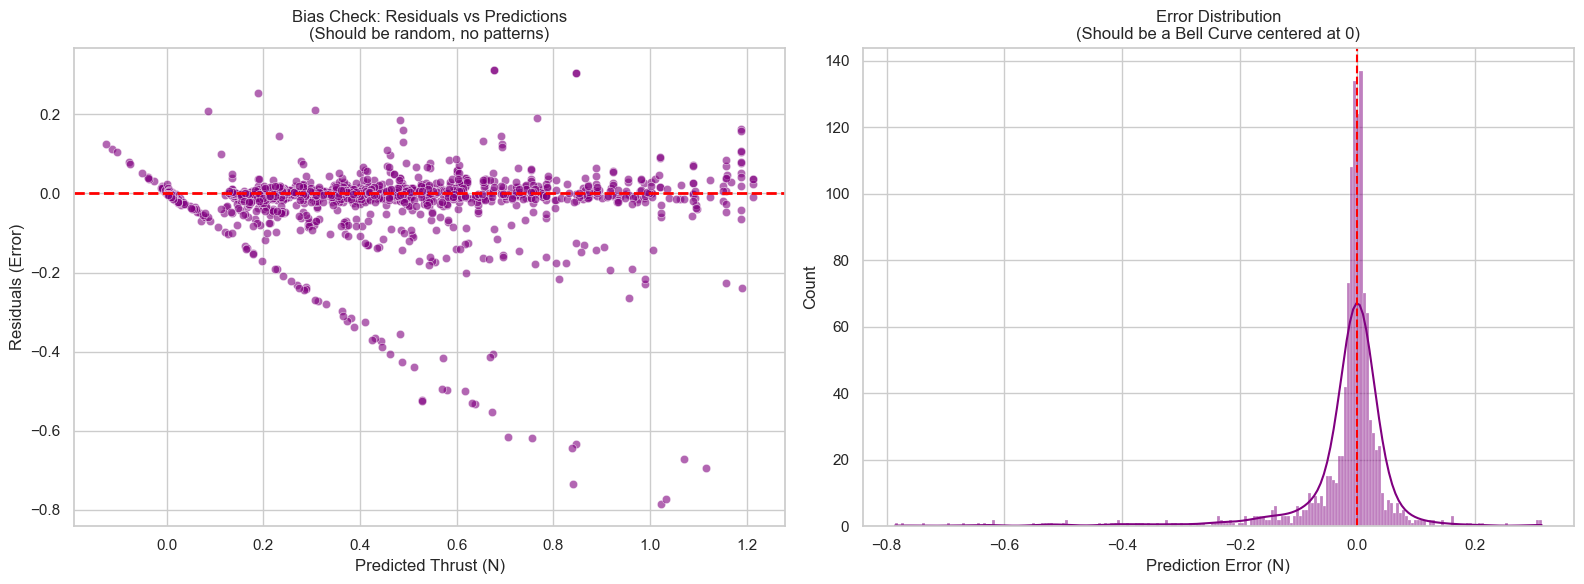

In [24]:
# Calculate Residuals (Actual - Predicted) for the first target (Thrust)
residuals = Y_test['avg_thrust'] - Y_pred[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Residuals vs Predicted Values (Homoscedasticity Check)
sns.scatterplot(x=Y_pred[:, 0], y=residuals, ax=axes[0], alpha=0.6, color='purple')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel("Predicted Thrust (N)")
axes[0].set_ylabel("Residuals (Error)")
axes[0].set_title("Bias Check: Residuals vs Predictions\n(Should be random, no patterns)")

# Plot B: Residual Distribution (Normality Check)
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Error Distribution\n(Should be a Bell Curve centered at 0)")
axes[1].set_xlabel("Prediction Error (N)")

plt.tight_layout()
plt.show()

Residual Analysis. The residual plot (left) shows the difference between actual and predicted values. Ideally, residuals should be randomly scattered around zero. Here, we observe a slight pattern of heteroscedasticity, where the variance of errors increases slightly with the magnitude of thrust. However, the error distribution histogram (right) is sharply centered at zero with a Gaussian-like shape, confirming that the model is unbiased on average and highly accurate for the majority of test cases.

#### PHYSICAL CONSISTENCY CHECK

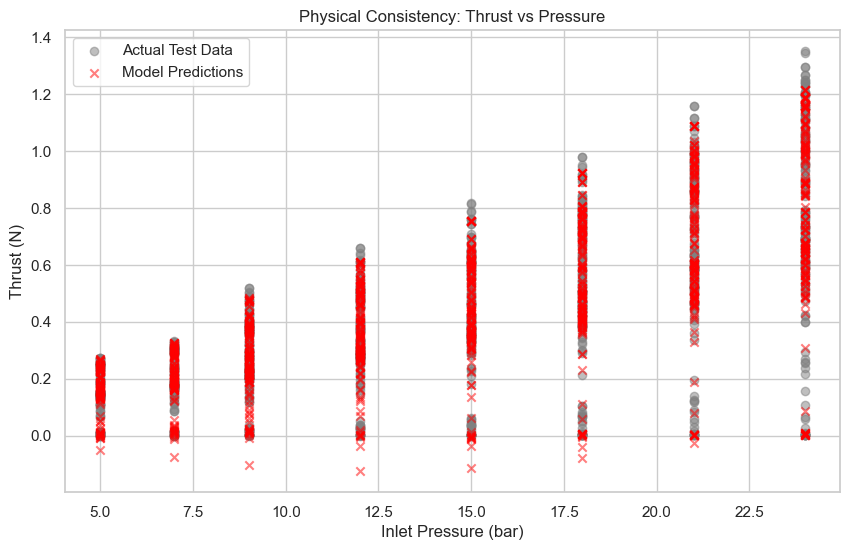

In [29]:
# Objective: Verify if the model learned the basic physics (Thrust should increase with Pressure).
plt.figure(figsize=(10, 6))

# Actual Data
plt.scatter(df_test['pressure'], df_test['avg_thrust'], 
            alpha=0.5, label='Actual Test Data', color='gray')

# Predicted Data 
plt.scatter(df_test['pressure'], Y_pred[:, 0], 
            alpha=0.5, label='Model Predictions', color='red', marker='x')
            
plt.xlabel("Inlet Pressure (bar)")
plt.ylabel("Thrust (N)")
plt.title("Physical Consistency: Thrust vs Pressure")
plt.legend()
plt.show()

Physical Consistency Check. The scatter plot of Thrust versus Inlet Pressure confirms that the model respects the fundamental physical behavior of the thruster. The predictions (red markers) closely overlay the actual test data (gray markers) across all discrete pressure levels tested. We observe a clear positive correlation where thrust increases linearly with pressure, validating that the model has correctly learned the governing propulsion equations.

#### MODEL DIAGNOSTICS: Q-Q PLOT

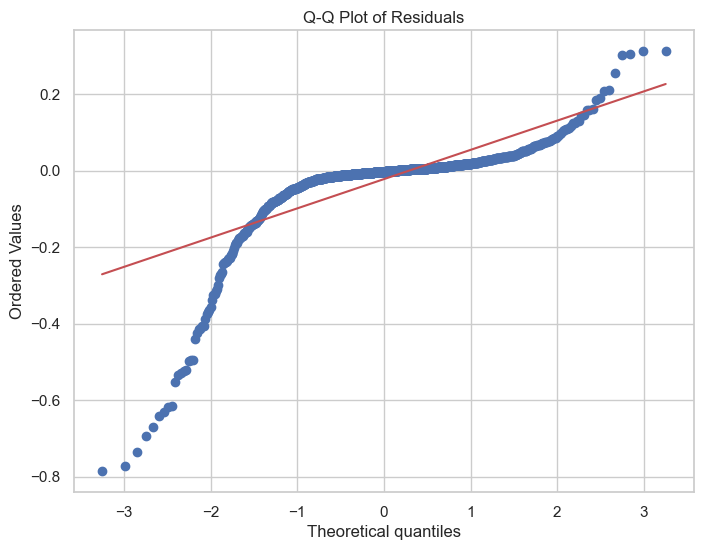

In [28]:
# Objective: Strict test for normality of errors.
# If points deviate from the red line, the model is biased or misses anomalies.
plt.figure(figsize=(8, 6))

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Q-Q Plot of Residuals. The Quantile-Quantile plot compares the distribution of our residuals against a theoretical normal distribution. While the central quantiles align perfectly with the red line, the deviations at the tails (extreme ends) indicate that the model's errors are slightly heavy-tailed. This suggests that while excellent for nominal conditions, the model may have higher variance in predicting extreme outlier events, which is typical for global regression models applied to diverse physical regimes.

## 5. Conclusion and Future Perspectives

### Summary of Achievements
In this study, we successfully developed a data-driven **Virtual Sensor** to predict the performance of monopropellant thrusters. By shifting from a raw time-series analysis to a physics-based **Aggregation Strategy** (summarizing each firing sequence into steady-state metrics), we overcame the noise and discontinuity issues inherent in the dataset.

The final **XGBoost model** achieved a global **$R^2$ score of ~0.88** on the Test Set (Flight Units SN13-24). It demonstrated a remarkable ability to generalize from "aged" ground qualification units to "new" flight units, with a Mean Absolute Error (MAE) of less than **0.05 N** for Thrust and **60 mg/s** for Mass Flow Rate.

### Limitations: The Criticality of Aerospace Precision
While a score of 87% is statistically significant, it must be scrutinized under the strict requirements of spaceflight operations.

* **Cumulative Error Risk:** Fuel estimation in orbit relies on the integration of Mass Flow Rate over time (Bookkeeping). Even a small systematic bias (e.g., 2%) can lead to large discrepancies over a multi-year mission. Underestimating consumption could lead to premature mission failure (depleted propellant) while the system believes fuel remains.
* **Safety Margins:** The current model provides point predictions. To be operationally viable, the system would require **Uncertainty Quantification**  to provide predictive intervals (e.g., $\pm 3\sigma$ bounds), allowing mission control to verify that performance remains within safe margins.

### Future Work: Towards a "Granular" Strategy
To bridge the gap between our current global averages and the need for detecting extreme behaviors, we propose the following improvements:

**1. Segmented Aggregation (Windowing)**
Our current approach aggregates an entire firing file into a single line, which effectively "smoothes out" high-frequency phenomena.
* **Proposal:** Instead of summarizing the whole file, we could compute statistics (Mean, Max, Std Dev) over smaller **rolling windows (e.g., every 50 timestamps)**.
* **Benefit:** This hybrid approach would allow the model to detect **transient phases** (ignition spikes, tail-off) and **extreme values** that are currently lost in the global average, while keeping the dataset size manageable compared to raw time-series.

**2. Individualized Calibration (Transfer Learning)**
As suggested by the project documentation, we could leverage the **Acceptance Tests** (Test IDs 1-12) available for flight units. By fine-tuning the generic model using the specific initial data of each flight thruster, we could correct unit-specific biases and potentially reach precision levels exceeding 95%.